<a href="https://colab.research.google.com/github/25ds3000042/PyTorch_DL/blob/main/PyTorch_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

load data

In [2]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 46.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.17MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.02MB/s]


Autoencoder

In [3]:
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 32)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):

        # Image → vector
        x = x.view(x.size(0), -1)

        # Compress
        encoded = self.encoder(x)

        # Reconstruct
        decoded = self.decoder(encoded)

        return decoded


In [4]:
model = Autoencoder()

In [5]:
criterion = nn.MSELoss()

In [6]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
epochs = 5

for epoch in range(epochs):

    total_loss = 0

    for images, _ in train_loader:

        # Forward pass
        output = model(images)

        # Compare output with original image
        loss = criterion(output, images.view(images.size(0), -1))

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{epochs}], "
        f"Loss: {total_loss / len(train_loader):.4f}"
    )

Epoch [1/5], Loss: 0.0352
Epoch [2/5], Loss: 0.0152
Epoch [3/5], Loss: 0.0115
Epoch [4/5], Loss: 0.0098
Epoch [5/5], Loss: 0.0089


In [8]:
# Get one batch
images, _ = next(iter(train_loader))

In [9]:
# Reconstruct images
with torch.no_grad():
    reconstructed = model(images)

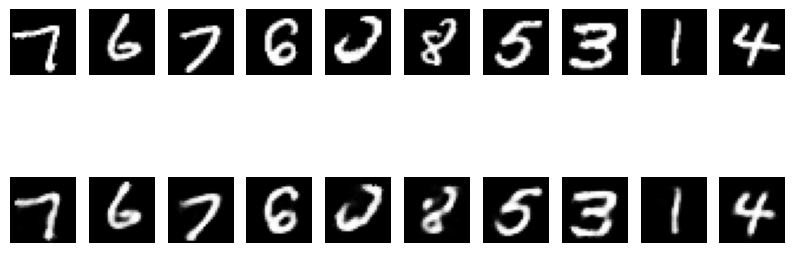

In [10]:
# Show original and reconstructed
plt.figure(figsize=(10, 4))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(
        reconstructed[i].reshape(28, 28),
        cmap="gray"
    )
    plt.axis("off")

plt.show()